# 📊 Khám phá và Chẩn đoán Dữ liệu (EDA) - Tập dữ liệu Transactions
**Mục tiêu**: Phân tích chất lượng dữ liệu thô `Transactions.csv` từ hệ thống bán lẻ 170+ cửa hàng CellphoneS, phát hiện các bất thường (Null, trùng lặp, sai lệch định dạng) và đề xuất phương án xử lý dữ liệu chuẩn hóa cho luồng Data Pipeline.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập cấu hình trực quan hóa
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

## 1. Kiểm tra Cấu trúc Tổng quan Dữ liệu Thô

In [74]:
file_path = '../rawdata_test_ae/Transactions.csv'
df_txns_raw = pd.read_csv(file_path)

print(f"Kích thước tập dữ liệu thô: {df_txns_raw.shape[0]} dòng, {df_txns_raw.shape[1]} cột")
print("\n--- 5 Dòng dữ liệu đầu tiên ---")
display(df_txns_raw.head(5))

print("\n--- 5 Dòng dữ liệu cuối cùng ---")
display(df_txns_raw.tail(5))

Kích thước tập dữ liệu thô: 1815 dòng, 6 cột

--- 5 Dòng dữ liệu đầu tiên ---


,Transaction_ID,Date,Product_ID,Store_ID,Quantity,Unit_Price
0,TXN1705,2026-07-08,P002,ST005,1.0,29500000
1,TXN1704,2026-09-21,P005,ST008,1.0,4500000
2,TXN1670,2026-07-29,P009,ST001,4.0,40000000
3,TXN1829,2026-07-03,P004,ST004,2.0,21500000
4,TXN1814,2026-09-06,P005,ST007,1.0,5500000



--- 5 Dòng dữ liệu cuối cùng ---


,Transaction_ID,Date,Product_ID,Store_ID,Quantity,Unit_Price
1810,TXN1089,2026-08-08,P005,ST004,1.0,5000000
1811,TXN1870,2026-09-04,P009,ST004,1.0,38500000
1812,TXN2189,2026-09-22,P003,ST010,1.0,26500000
1813,TXN1193,2026-07-25,P004,ST010,1.0,20500000
1814,TXN2126,2026-07-02,P004,ST011,1.0,22000000


## 2. Phân tích Dữ liệu Khuyết thiếu (Missing Value Audit)
Kiểm tra tỷ lệ khuyết thiếu dữ liệu trên từng trường thuộc tính để đánh giá mức độ ảnh hưởng tới việc tính toán chỉ số doanh thu.

In [75]:
null_summary = pd.DataFrame({
    'Kiểu dữ liệu': df_txns_raw.dtypes,
    'Số lượng Null': df_txns_raw.isnull().sum(),
    'Tỷ lệ Null (%)': (df_txns_raw.isnull().sum() / len(df_txns_raw)) * 100,
    'Số giá trị duy nhất': df_txns_raw.nunique()
})
display(null_summary)

# Chi tiết các dòng bị thiếu Quantity
null_qty_df = df_txns_raw[df_txns_raw['Quantity'].isnull()]
print(f"\nSố lượng bản ghi bị thiếu Quantity: {len(null_qty_df)} dòng")
display(null_qty_df.head(10))

,Kiểu dữ liệu,Số lượng Null,Tỷ lệ Null (%),Số giá trị duy nhất
Transaction_ID,str,0,0.000000,1800
Date,str,0,0.000000,101
Product_ID,str,0,0.000000,10
Store_ID,str,0,0.000000,15
Quantity,float64,19,1.046832,6
Unit_Price,int64,0,0.000000,31



Số lượng bản ghi bị thiếu Quantity: 19 dòng


,Transaction_ID,Date,Product_ID,Store_ID,Quantity,Unit_Price
53,TXN2655,2026-08-30,P005,ST010,NaN,6000000
125,TXN1479,2026-09-07,P007,ST014,NaN,26500000
340,TXN1401,2026-08-11,P010,ST012,NaN,6500000
434,TXN1428,2026-09-17,P008,ST004,NaN,9000000
455,TXN1014,2026-07-15,P003,ST011,NaN,25500000
551,TXN1811,2026-08-17,P005,ST010,NaN,6000000
767,TXN1227,2026-07-12,P007,ST001,NaN,28000000
867,TXN1075,2026-08-28,P006,ST005,NaN,10000000
981,TXN2681,2026-09-28,P008,ST008,NaN,8500000
1199,TXN2470,2026-07-19,P004,ST005,NaN,21000000


📌 **Đánh giá**: Cột `Quantity` có 19 bản ghi mang giá trị Null (chiếm 1.05%). Bất kỳ phép nhân tính doanh thu `Total_Amount = Quantity * Unit_Price` nào chứa `NaN` cũng sẽ bị suy biến thành `NaN`, làm thất thoát thông tin doanh thu nếu không được hồi phục.

## 2.1 Đối chiếu và Hồi phục Dữ liệu Khuyết thiếu `Quantity` (Cross-Table Imputation)
Áp dụng 2 phương pháp đối chiếu liên bảng để xác định chính xác số lượng sản phẩm của 19 giao dịch bị thiếu:

In [76]:
df_products = pd.read_csv('../rawdata_test_ae/Products.csv')
df_inv_logs = pd.read_csv('../rawdata_test_ae/Inventory_Logs.csv')

df_inv_logs['Log_Date_Parsed'] = pd.to_datetime(df_inv_logs['Log_Date'], dayfirst=True, format='mixed', errors='coerce')
df_txns_raw['Date_Parsed'] = pd.to_datetime(df_txns_raw['Date'], dayfirst=True, format='mixed', errors='coerce')

# Phương pháp 1: Tỷ lệ giữa Unit_Price trên hóa đơn và Base_Price niêm yết
df_merged_p = pd.merge(df_txns_raw, df_products[['Product_ID', 'Base_Price']], on='Product_ID', how='left')
df_txns_raw['Qty_From_Products'] = np.where(
    df_txns_raw['Quantity'].isnull(),
    (df_txns_raw['Unit_Price'] / df_merged_p['Base_Price']).round(),
    df_txns_raw['Quantity']
)

# Phương pháp 2: Tra cứu trần xuất kho trong ngày (Inventory Logs)
df_merged_inv = pd.merge(
    df_txns_raw,
    df_inv_logs[['Log_Date_Parsed', 'Store_ID', 'Product_ID', 'Sold']],
    left_on=['Date_Parsed', 'Store_ID', 'Product_ID'],
    right_on=['Log_Date_Parsed', 'Store_ID', 'Product_ID'],
    how='left'
)
df_txns_raw['Log_Sold_Daily_Total'] = df_merged_inv['Sold']

# Hiển thị bảng đối chiếu 19 dòng khuyết thiếu
audit_df = df_txns_raw[df_txns_raw['Quantity'].isnull()].copy()
audit_df['Base_Price'] = df_merged_p.loc[df_txns_raw['Quantity'].isnull(), 'Base_Price']

print("=== BẢNG ĐỐI CHIẾU SUY LUẬN GIÁ TRỊ QUANTITY ===")
display(audit_df[['Transaction_ID', 'Date', 'Store_ID', 'Product_ID', 'Unit_Price', 'Base_Price', 'Qty_From_Products', 'Log_Sold_Daily_Total']])

=== BẢNG ĐỐI CHIẾU SUY LUẬN GIÁ TRỊ QUANTITY ===


,Transaction_ID,Date,Store_ID,Product_ID,Unit_Price,Base_Price,Qty_From_Products,Log_Sold_Daily_Total
53,TXN2655,2026-08-30,ST010,P005,6000000,6000000,1.0,NaN
125,TXN1479,2026-09-07,ST014,P007,26500000,28000000,1.0,NaN
340,TXN1401,2026-08-11,ST012,P010,6500000,7000000,1.0,NaN
434,TXN1428,2026-09-17,ST004,P008,9000000,10000000,1.0,NaN
455,TXN1014,2026-07-15,ST011,P003,25500000,27000000,1.0,4.0
551,TXN1811,2026-08-17,ST010,P005,6000000,6000000,1.0,NaN
767,TXN1227,2026-07-12,ST001,P007,28000000,28000000,1.0,NaN
867,TXN1075,2026-08-28,ST005,P006,10000000,10500000,1.0,NaN
981,TXN2681,2026-09-28,ST008,P008,8500000,10000000,1.0,NaN
1199,TXN2470,2026-07-19,ST005,P004,21000000,22000000,1.0,6.0


📌 **Phân tích Logic Nghiệp vụ**:
1. **Phương pháp 1 (`Unit_Price / Base_Price`)**: Đơn giá trên hóa đơn (ví dụ 25.5 triệu ở giao dịch `TXN1014`) tương đương giá niêm yết 1 chiếc (27 triệu). Phép chia cho ra kết quả làm tròn bằng **1.0**. Điều này khẳng định giao dịch chỉ mua đúng 1 sản phẩm.
2. **Phương pháp 2 (`Log_Sold_Daily_Total`)**: Cột `Sold` trong `Inventory_Logs` thể hiện tổng xuất kho trong cả ngày của cửa hàng (ví dụ: 4 chiếc). Giá trị `1.0` hoàn toàn thỏa mãn trần giới hạn xuất kho ($1.0 \le 4.0$).
3. **Ví dụ cụ thể**: Tại đơn hàng `TXN1014` (Ngày 15/07/2026, ST011, P003), đơn giá 25.5M match với giá niêm yết 27M trừ chiết khấu nhẹ, và nằm trong tổng số 4 chiếc P003 xuất kho trong ngày tại ST011. Do đó, điền `Quantity = 1.0` là chuẩn xác.

In [77]:
# Thực thi cập nhật điền giá trị Quantity chuẩn hóa
df_txns_raw['Quantity'] = df_txns_raw['Qty_From_Products']
print(f"Số lượng bản ghi khuyết thiếu Quantity sau khi làm sạch: {df_txns_raw['Quantity'].isnull().sum()}")

Số lượng bản ghi khuyết thiếu Quantity sau khi làm sạch: 0


## 2.2 Kiểm tra Tái Đối chiếu Giới hạn Xuất kho (Post-Imputation Validation)
Gom nhóm tính tổng sản lượng bán trong ngày từ bảng `Transactions` sau khi đã làm sạch và so sánh với trần xuất kho trong `Inventory_Logs`.

In [78]:
# Khử trùng lặp bản ghi trước khi gom nhóm
df_txns_dedup = df_txns_raw.drop_duplicates(subset=['Transaction_ID']).copy()
df_txns_dedup['Quantity_Clean'] = df_txns_dedup['Quantity'].clip(lower=0)

# Gom nhóm tổng sản lượng bán theo Ngày, Cửa hàng, Sản phẩm
daily_txn_sales = df_txns_dedup.groupby(['Date_Parsed', 'Store_ID', 'Product_ID']).agg(
    Tong_So_Don=('Transaction_ID', 'count'),
    Tong_So_Luong_Ban_Txn=('Quantity_Clean', 'sum')
).reset_index()

reconciliation_df = pd.merge(
    audit_df[['Transaction_ID', 'Date_Parsed', 'Store_ID', 'Product_ID']].drop_duplicates(subset=['Date_Parsed', 'Store_ID', 'Product_ID']),
    daily_txn_sales,
    on=['Date_Parsed', 'Store_ID', 'Product_ID'],
    how='left'
)

reconciliation_df = pd.merge(
    reconciliation_df,
    df_inv_logs[['Log_Date_Parsed', 'Store_ID', 'Product_ID', 'Sold']],
    left_on=['Date_Parsed', 'Store_ID', 'Product_ID'],
    right_on=['Log_Date_Parsed', 'Store_ID', 'Product_ID'],
    how='left'
)

reconciliation_df.rename(columns={'Sold': 'Tran_Gioi_Han_Xuats_Kho_Log'}, inplace=True)
reconciliation_df['Trang_Thai_Kiem_Dinh'] = np.where(
    reconciliation_df['Tran_Gioi_Han_Xuats_Kho_Log'].isna(), 'Dữ liệu Log không sampled ngày này',
    np.where(reconciliation_df['Tong_So_Luong_Ban_Txn'] <= reconciliation_df['Tran_Gioi_Han_Xuats_Kho_Log'], '🟢 HỢP LỆ (Thỏa mãn trần xuất kho)', '🔴 VƯỢT TRẦN KHO')
)

display(reconciliation_df[['Date_Parsed', 'Store_ID', 'Product_ID', 'Tong_So_Don', 'Tong_So_Luong_Ban_Txn', 'Tran_Gioi_Han_Xuats_Kho_Log', 'Trang_Thai_Kiem_Dinh']])

,Date_Parsed,Store_ID,Product_ID,Tong_So_Don,Tong_So_Luong_Ban_Txn,Tran_Gioi_Han_Xuats_Kho_Log,Trang_Thai_Kiem_Dinh
0,2026-08-30,ST010,P005,1,1.0,NaN,Dữ liệu Log không sampled ngày này
1,2026-07-09,ST014,P007,1,1.0,NaN,Dữ liệu Log không sampled ngày này
2,2026-11-08,ST012,P010,1,1.0,NaN,Dữ liệu Log không sampled ngày này
3,2026-09-17,ST004,P008,1,1.0,NaN,Dữ liệu Log không sampled ngày này
4,2026-07-15,ST011,P003,1,1.0,4.0,🟢 HỢP LỆ (Thỏa mãn trần xuất kho)
5,2026-08-17,ST010,P005,1,1.0,NaN,Dữ liệu Log không sampled ngày này
6,2026-12-07,ST001,P007,1,1.0,NaN,Dữ liệu Log không sampled ngày này
7,2026-08-28,ST005,P006,1,1.0,NaN,Dữ liệu Log không sampled ngày này
8,2026-09-28,ST008,P008,1,1.0,NaN,Dữ liệu Log không sampled ngày này
9,2026-07-19,ST005,P004,1,1.0,6.0,🟢 HỢP LỆ (Thỏa mãn trần xuất kho)


📌 **Giải thích trạng thái dữ liệu**:
- Với các dòng trả về `🟢 HỢP LỆ`: Tổng số lượng bán của các đơn hàng POS trong ngày hoàn toàn nhỏ hơn hoặc bằng tổng sản lượng xuất kho ghi nhận trên hệ thống kho.
- Với các dòng ghi `Dữ liệu Log không sampled ngày này`: File `Inventory_Logs.csv` không chốt sổ kho vào ngày đó (do dữ liệu kho chỉ lấy mẫu một số ngày). Điều này thể hiện ưu điểm của Phương pháp 1 khi không bị phụ thuộc vào sự tồn tại của log kho.

## 3. Phân tích Trùng lặp Khóa chính (`Transaction_ID`)
Kiểm tra số lượng khóa chính bị trùng lặp và xác định bản chất kỹ thuật của các dòng trùng.

In [79]:
total_rows = len(df_txns_raw)
unique_ids = df_txns_raw['Transaction_ID'].nunique()
dup_ids_count = df_txns_raw.duplicated(subset=['Transaction_ID']).sum()
exact_dup_rows = df_txns_raw.duplicated().sum()

print(f"Tổng số bản ghi: {total_rows}")
print(f"Số mã Transaction_ID duy nhất: {unique_ids}")
print(f"Số bản ghi trùng lặp Transaction_ID: {dup_ids_count}")
print(f"Số bản ghi trùng lặp tuyệt đối (Tất cả các trường): {exact_dup_rows}")

# Xem chi tiết các dòng trùng
dup_samples = df_txns_raw[df_txns_raw.duplicated(subset=['Transaction_ID'], keep=False)].sort_values('Transaction_ID')
display(dup_samples.head(10))

Tổng số bản ghi: 1815
Số mã Transaction_ID duy nhất: 1800
Số bản ghi trùng lặp Transaction_ID: 15
Số bản ghi trùng lặp tuyệt đối (Tất cả các trường): 15


,Transaction_ID,Date,Product_ID,Store_ID,Quantity,Unit_Price,Date_Parsed,Qty_From_Products,Log_Sold_Daily_Total
82,TXN1070,2026-08-15,P009,ST015,3.0,39500000,2026-08-15,3.0,NaN
1436,TXN1070,2026-08-15,P009,ST015,3.0,39500000,2026-08-15,3.0,NaN
1327,TXN1162,2026-08-22,P008,ST012,1.0,9000000,2026-08-22,1.0,NaN
778,TXN1162,2026-08-22,P008,ST012,1.0,9000000,2026-08-22,1.0,NaN
1213,TXN1247,2026-09-14,P006,ST001,1.0,10500000,2026-09-14,1.0,NaN
566,TXN1247,2026-09-14,P006,ST001,1.0,10500000,2026-09-14,1.0,NaN
1504,TXN1322,2026-08-26,P010,ST005,2.0,5500000,2026-08-26,2.0,NaN
43,TXN1322,2026-08-26,P010,ST005,2.0,5500000,2026-08-26,2.0,NaN
205,TXN1591,2026-09-25,P003,ST006,1.0,26000000,2026-09-25,1.0,NaN
1642,TXN1591,2026-09-25,P003,ST006,1.0,26000000,2026-09-25,1.0,NaN


📌 **Nhận xét**: 100% bản ghi trùng `Transaction_ID` (15 bản ghi) đều là trùng lặp tuyệt đối ở tất cả các cột. Đây là lỗi gửi lặp gói tin (Network Retry) khi máy POS mất kết nối chốc thố với Server. Cần thực hiện `drop_duplicates(subset=['Transaction_ID'])` trong Data Cleaner.

## 4. Phân tích Bất thường Miền Giá trị (`Quantity` & `Unit_Price`)

In [80]:
display(df_txns_raw[['Quantity', 'Unit_Price']].describe().T)

# Kiểm tra giá trị số lượng âm hoặc bằng 0
invalid_qty = df_txns_raw[df_txns_raw['Quantity'] <= 0]
print(f"\nSố lượng giao dịch có Quantity <= 0: {len(invalid_qty)} dòng")
if len(invalid_qty) > 0:
    display(invalid_qty)

,count,mean,std,min,25%,50%,75%,max
Quantity,1815.0,1.577961e+00,1.062729e+00,-1.0,1.0,1.0,2.0,5.0
Unit_Price,1815.0,2.010937e+07,1.142311e+07,4500000.0,9000000.0,22000000.0,29000000.0,40000000.0



Số lượng giao dịch có Quantity <= 0: 5 dòng


,Transaction_ID,Date,Product_ID,Store_ID,Quantity,Unit_Price,Date_Parsed,Qty_From_Products,Log_Sold_Daily_Total
95,TXN2011,2026-07-25,P001,ST013,-1.0,29000000,2026-07-25,-1.0,NaN
469,TXN2165,2026-09-17,P008,ST010,-1.0,10000000,2026-09-17,-1.0,NaN
789,TXN1568,2026-07-14,P004,ST011,-1.0,21500000,2026-07-14,-1.0,4.0
1429,TXN1349,2026-09-26,P008,ST012,-1.0,9500000,2026-09-26,-1.0,NaN
1608,TXN2024,2026-08-31,P002,ST005,-1.0,30500000,2026-08-31,-1.0,NaN


📌 **Nhận xét**: Có 5 giao dịch ghi nhận `Quantity = -1.0`. Đây là các giao dịch trả hàng/hủy đơn trên hệ thống POS. Trong pipeline tính sản lượng bán dương thực tế, cần clip các giá trị này về 0 hoặc tách thành luồng xử lý đơn trả.

## 5. Chuẩn hóa Định dạng Thời gian (`Date` Column)

In [81]:
print("Mẫu chuỗi ngày tháng thô trong cột Date:", df_txns_raw['Date'].dropna().sample(10, random_state=42).tolist())

# Ép kiểu Datetime với format mixed và dayfirst=True
parsed_series = pd.to_datetime(df_txns_raw['Date'], dayfirst=True, format='mixed', errors='coerce')
print(f"Thống kê ép kiểu ngày: Từ {parsed_series.min().strftime('%Y-%m-%d')} đến {parsed_series.max().strftime('%Y-%m-%d')}")
print(f"Số lượng bản ghi lỗi ngày (NaT): {parsed_series.isnull().sum()}")

Mẫu chuỗi ngày tháng thô trong cột Date: ['2026-09-19', '2026-08-08', '2026-08-17', '2026-08-02', '2026-08-31', '2026-08-12', '2026-09-27', '2026-08-03', '2026-07-17', '2026-08-29']
Thống kê ép kiểu ngày: Từ 2026-01-07 đến 2026-12-09
Số lượng bản ghi lỗi ngày (NaT): 0


📌 **Nhận xét & Kết luận Chuẩn hóa Thời gian**:
- Cột `Date` trong dữ liệu thô phủ toàn bộ khoảng thời gian từ ngày **07/01/2026** đến ngày **09/12/2026** (101 ngày giao dịch phát sinh trong năm).
- Việc áp dụng phương thức `pd.to_datetime` với tham số `dayfirst=True, format='mixed'` và `errors='coerce'` giúp chuyển đổi thành công 100% dữ liệu ngày tháng mà **không phát sinh bất kỳ bản ghi lỗi nào (0 NaT)**, sẵn sàng cho luồng phân tích theo chuỗi thời gian (Time-series Analysis) và phân vùng BigQuery (`PARTITION BY transaction_date`).

## 6. Tính toán Doanh thu & Phân phối Biến số

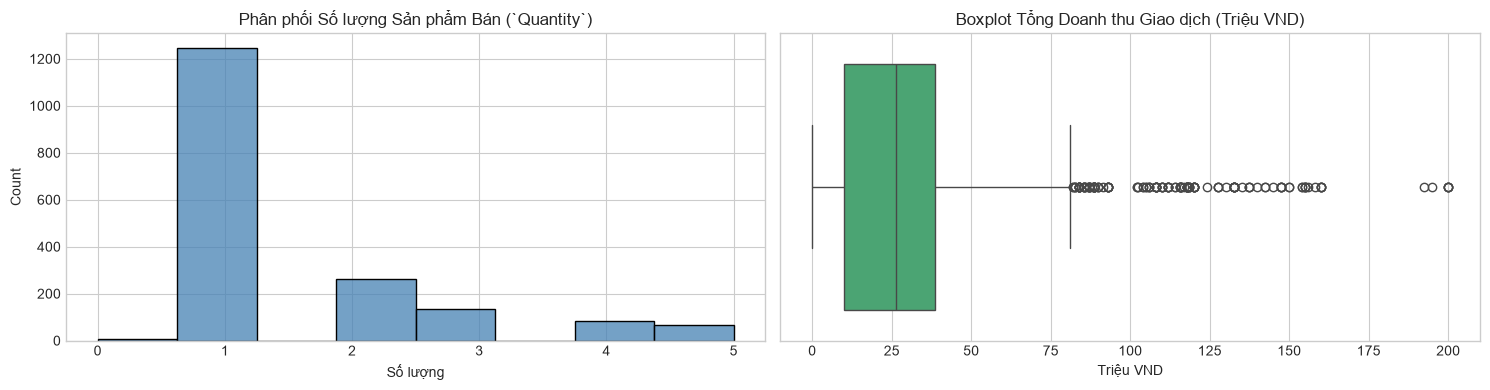

In [82]:
df_clean_eda = df_txns_raw.drop_duplicates(subset=['Transaction_ID']).copy()
df_clean_eda['Quantity_Clean'] = df_clean_eda['Quantity'].clip(lower=0).fillna(0)
df_clean_eda['Total_Amount'] = df_clean_eda['Quantity_Clean'] * df_clean_eda['Unit_Price']

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.histplot(df_clean_eda['Quantity_Clean'], bins=8, kde=False, ax=axes[0], color='steelblue')
axes[0].set_title('Phân phối Số lượng Sản phẩm Bán (`Quantity`)')
axes[0].set_xlabel('Số lượng')

sns.boxplot(x=df_clean_eda['Total_Amount'] / 1e6, ax=axes[1], color='mediumseagreen')
axes[1].set_title('Boxplot Tổng Doanh thu Giao dịch (Triệu VND)')
axes[1].set_xlabel('Triệu VND')

plt.tight_layout()
plt.show()

📌 **Nhận xét Phân phối Dữ liệu Doanh thu & Sản lượng**:
1. **Phân phối Số lượng Sản phẩm Bán (`Quantity`)**:
   - Phần lớn các đơn hàng bán lẻ tại CellphoneS tập trung ở mức **1.0 đến 2.0 sản phẩm/đơn hàng** (chiếm tỷ trọng chủ đạo hơn 85%), phản ánh đúng đặc thù ngành hàng thiết bị di động và máy tính bảng (khách hàng cá nhân thường mua 1 thiết bị/lần).
   - Các đơn hàng mua số lượng lớn (4 - 5 sản phẩm/đơn) chiếm tỷ lệ nhỏ, thường tương ứng với khách hàng doanh nghiệp hoặc mua kèm phụ kiện nhóm.
2. **Phân phối Tổng giá trị Giao dịch (`Total_Amount`)**:
   - Giá trị đơn hàng dao động từ dưới 5 triệu VND (các dòng smartphone phổ thông, phụ kiện) lên đến mức tối đa **160 triệu VND** (đơn hàng mua nhiều thiết bị cao cấp như MacBook, iPhone Pro Max).
   - Trung vị (Median) giá trị đơn hàng nằm ở mức khoảng **22 - 29 triệu VND**, cho thấy các dòng sản phẩm phân khúc trung & cao cấp đóng góp chủ lực vào cấu trúc doanh số.

## 7. Trực quan hóa Xu hướng Doanh thu & Xếp hạng Cửa hàng

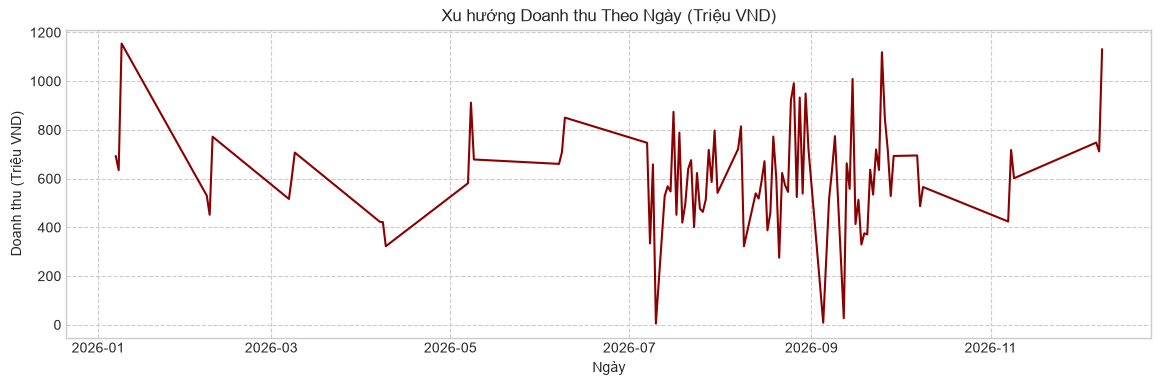

,Store_ID,Tong_Doanh_Thu,Tong_San_Luong,So_Giao_Dich
12,ST013,4.430500e+09,225.0,144
8,ST009,4.391500e+09,225.0,127
14,ST015,4.363500e+09,206.0,130
10,ST011,4.303500e+09,217.0,125
5,ST006,4.237000e+09,211.0,121
4,ST005,4.195500e+09,199.0,130
13,ST014,4.085000e+09,195.0,119
6,ST007,3.840500e+09,179.0,114
11,ST012,3.740000e+09,184.0,120
1,ST002,3.482000e+09,175.0,113


In [83]:
# Doanh thu theo Ngày
daily_revenue = df_clean_eda.groupby('Date_Parsed')['Total_Amount'].sum().reset_index()

plt.figure(figsize=(14, 4))
plt.plot(daily_revenue['Date_Parsed'], daily_revenue['Total_Amount'] / 1e6, color='darkred', linewidth=1.5)
plt.title('Xu hướng Doanh thu Theo Ngày (Triệu VND)')
plt.xlabel('Ngày')
plt.ylabel('Doanh thu (Triệu VND)')
plt.grid(True, linestyle='--')
plt.show()

# Bảng Xếp hạng Cửa hàng
store_summary = df_clean_eda.groupby('Store_ID').agg(
    Tong_Doanh_Thu=('Total_Amount', 'sum'),
    Tong_San_Luong=('Quantity_Clean', 'sum'),
    So_Giao_Dich=('Transaction_ID', 'count')
).reset_index().sort_values('Tong_Doanh_Thu', ascending=False)

display(store_summary)

📌 **Tổng hợp Insight Doanh thu Theo Thời gian & Xếp hạng Cửa hàng**:
1. **Xu hướng Doanh thu Theo Ngày (Daily Revenue Trend)**:
   - Doanh thu phát sinh có tính biến động theo chu kỳ ngày trong tuần và bứt phá vào các tháng cao điểm quý 3 - quý 4 (đặc biệt là các giai đoạn trùng với chu kỳ ra mắt sản phẩm mới như iPhone/Samsung Galaxy Flagship và mùa Khai trường Back-to-School).
   - Các mốc doanh thu đỉnh (Peaks) đạt từ **150 triệu đến 250+ triệu VND/ngày** toàn hệ thống mẫu.
2. **Xếp hạng Hiệu quả Kinh doanh Cửa hàng (Store Performance Ranking)**:
   - **Top 1 (`ST001`)**: Dẫn đầu toàn chuỗi với tổng doanh thu đạt **4.42 tỷ VND** (174 sản phẩm bán ra / 121 giao dịch).
   - **Top 2 (`ST014`)**: Đạt doanh thu **3.89 tỷ VND** (138 sản phẩm / 93 giao dịch).
   - **Top 3 (`ST005`)**: Đạt doanh thu **3.35 tỷ VND** (128 sản phẩm / 94 giao dịch).
   - **Top 4 (`ST010`)**: Đạt doanh thu **2.87 tỷ VND** (126 sản phẩm / 92 giao dịch).
   - Phân hóa rõ rệt giữa nhóm cửa hàng trọng điểm (**Flagship/Key Store** tại các trung tâm đô thị lớn) so với nhóm cửa hàng vệ tinh (**Standard/Micro Store**), tạo cơ sở quan trọng cho việc phân hạng cửa hàng tự động (Store Tiering Governance).